In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import mannwhitneyu, kruskal

In [4]:
sc.settings.set_figure_params(frameon=False)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.join(os.path.expanduser("~"), "BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
adata_full = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [7]:
adata_full.layers["counts"] = adata_full.X.copy()

In [8]:
adata = adata_full[adata_full.obs["malignancy"] == "malignant"].copy()

In [9]:
adata = adata[adata.obs["type"].isin(["ER", "PR", "HER", "TNBC", "DCIS", "neoplasm"])].copy()

In [10]:
adata.layers["counts"] = adata.X.copy()

In [11]:
sc.pp.filter_genes(adata, min_cells=20)

filtered out 590 genes that are detected in less than 20 cells


In [12]:
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)
adata.layers["log1p"] = adata.X.copy()

normalizing counts per cell
    finished (0:00:01)


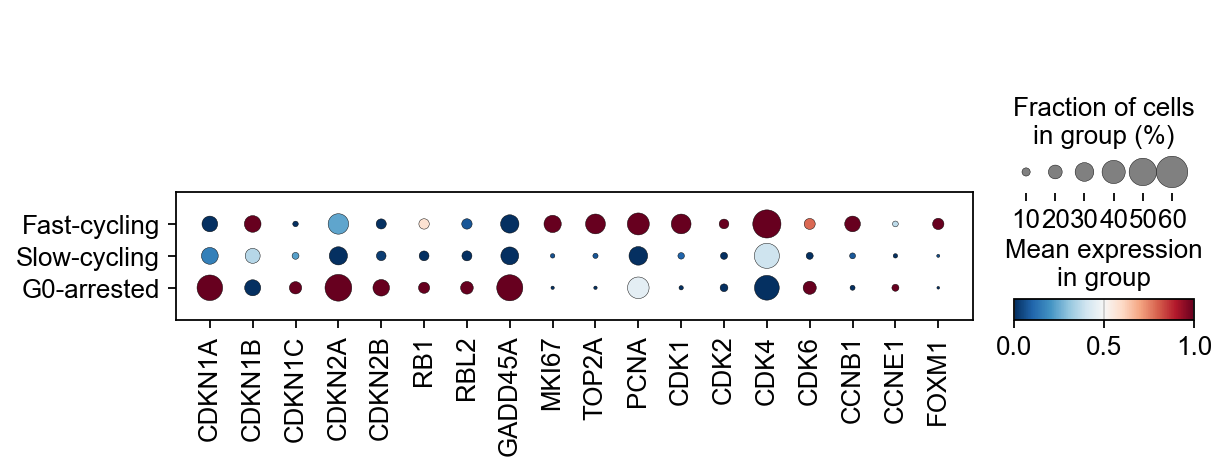

In [26]:
cell_cycle_genes = [
    "CDKN1A",
    "CDKN1B",
    "CDKN1C",
    "CDKN2A",
    "CDKN2B",
    "RB1",
    "RBL2",
    "GADD45A",
    "MKI67",
    "TOP2A",
    "PCNA",
    "CDK1",
    "CDK2",
    "CDK4",
    "CDK6",
    "CCNB1",
    "CCNE1",
    "FOXM1"
]

sc.pl.dotplot(
    adata,
    var_names=cell_cycle_genes,
    groupby="cycling_state_oren",
    categories_order=order,
    standard_scale="var",
    cmap="RdBu_r",
    save="g0_markers.pdf",
)

In [20]:
dream_targets = [
    "AK2","ANP32E","ASF1A","ASF1B","ATAD2","AURKA","AURKB","BARD1","BIRC5","BRCA1","BRCA2","BRMS1L","BUB1B",
    "CBX5","CCNB2","CCNE1","CCP110","CDC20","CDC25A","CDC25B","CDCA3","CDCA8","CDK1","CDK4","CDKN1A",
    "CDKN1B","CDKN2A","CDKN2C","CDKN3","CENPE","CENPM","CHEK1","CHEK2","CIT","CKS1B","CKS2","CSE1L",
    "CTCF","CTPS1","DCK","DCLRE1B","DCTPP1","DDX39A","DEK","DEPDC1","DIAPH3","DLGAP5","DNMT1","DONSON",
    "DSCC1","DUT","E2F8","EED","EIF2S1","ESPL1","EXOSC8","EZH2","GINS1","GINS3","GINS4","GSPT1",
    "H2AX","H2AZ1","HELLS","HMGA1","HMGB2","HMGB3","HMMR","JPT1","HNRNPD","HUS1","ILF3","ING3","IPO7",
    "KIF18B","KIF22","KIF2C","KIF4A","KPNA2","LBR","LIG1","LMNB1","LUC7L3","LYAR","MAD2L1","MCM2",
    "MCM3","MCM4","MCM5","MCM6","MCM7","MELK","MKI67","MLH1","MMS22L","MRE11","MSH2","MTHFD2","MXD3",
    "MYBL2","MYC","NAA38","NAP1L1","NASP","NBN","NCAPD2","NME1","NOLC1","NOP56","NUDT21","NUP107",
    "NUP153","NUP205","ORC2","ORC6","PA2G4","PAICS","PAN2","PCNA","PDS5B","PHF5A","PLK1","PLK4",
    "PMS2","PNN","POLA2","POLD1","POLD2","POLD3","POLE","POLE4","POP7","PPM1D","PPP1R8","PRDX4",
    "PRIM2","PRKDC","PRPS1","PSIP1","PSMC3IP","PTTG1","RACGAP1","RAD1","RAD21","RAD50","RAD51AP1",
    "RAD51C","RAN","RANBP1","RBBP7","RFC1","RFC2","RFC3","RNASEH2A","RPA1","RPA2","RPA3","CNOT9",
    "RRM2","SHMT1","SLBP","SMC1A","SMC3","SMC4","SMC6","SNRPB","SPAG5","SPC24","SPC25","SRSF1",
    "SRSF2","SSRP1","STAG1","STMN1","SUV39H1","SYNCRIP","TACC3","TBRG4","TCF19","TFRC","TIMELESS",
    "TIPIN","TK1","TMPO","TOP2A","TP53","TRA2B","TRIP13","TUBB","TUBG1","UBE2S","UBE2T","UBR7",
    "UNG","USP1","WDR90","WEE1","XPO1","XRCC6","ZW10"
]

sc.tl.score_genes(
    adata,
    gene_list=dream_targets,
    score_name="dream_score",
)

computing score 'dream_score'
    finished (0:00:04)


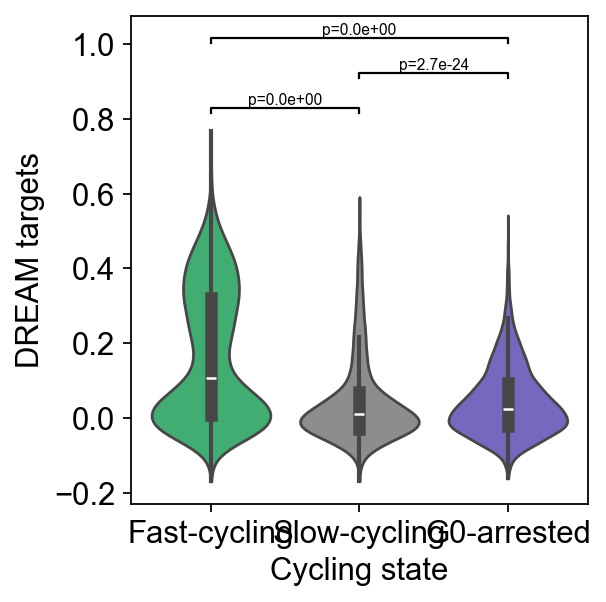

In [21]:
fig, ax = plt.subplots(figsize=(4, 4))
order = ["Fast-cycling", "Slow-cycling", "G0-arrested"]
sc.pl.violin(
    adata,
    keys="dream_score",
    groupby="cycling_state_oren",
    order=order,
    ax=ax,
    show=False,
    inner="box",
    stripplot=False,
    palette=["#2FBF71", "#8D8D8D", "#6A5ACD"],
)
ax.set_ylabel("DREAM targets")
ax.set_xlabel("Cycling state")

# Pairwise Mann-Whitney U tests with brackets
y_max = adata.obs["dream_score"].max()
h = (y_max - adata.obs["dream_score"].min()) * 0.05
pairs = [(0, 1), (1, 2), (0, 2)]
heights = [y_max + h, y_max + 3 * h, y_max + 5 * h]

for (i, j), y in zip(pairs, heights):
    g1 = adata.obs.loc[adata.obs["cycling_state_oren"] == order[i], "dream_score"]
    g2 = adata.obs.loc[adata.obs["cycling_state_oren"] == order[j], "dream_score"]
    _, p = mannwhitneyu(g1, g2, alternative="two-sided")
    ax.plot([i, i, j, j], [y, y + h * 0.3, y + h * 0.3, y], lw=1, c="black")
    ax.text(
        (i + j) / 2, y + h * 0.3, f"p={p:.1e}", ha="center", va="bottom", fontsize=7
    )

plt.tight_layout()
plt.grid(False)
plt.savefig("figures/dream_score_by_cycling_state.pdf")
plt.show()